# My First LSTM Model - Stock Price Prediction

Hello and welcome to this Jupyter Notebook! In this exercise, we will be developing a Long Short Term Memory (LSTM) model to predict stock prices, combining key concepts from both the fields of deep learning and finance. The LSTM model, a type of Recurrent Neural Network (RNN), is well-suited to predict time series data due to its capability to remember long-term dependencies, which is crucial for understanding trends in stock market data.

# Start

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import yfinance as yf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.metrics import Precision

In [122]:
# Define the stock symbol
stock_symbol = 'VUSA.L'  # Vanguard S&P500

# Define the start and end dates for data retrieval
start_date = '2021-01-01'
end_date = '2023-07-13'

# Retrieve stock data from Yahoo Finance
stock_data = yf.download(stock_symbol, start=start_date, end=end_date)

# Extract the 'Open' and 'Close' prices
prices = stock_data[['Open', 'Close']].values

# Calculate price movement: 0 for "down" and 1 for "up"  --> Therefore, this is a classification problem.
price_movement = np.where(prices[:, 1] - prices[:, 0] >= 0, 1, 0)

[*********************100%***********************]  1 of 1 completed


In [123]:
# Scale the data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

In [124]:
# Split the data into training and testing sets
train_size = int(len(scaled_prices) * 0.8)
test_size = len(scaled_prices) - train_size
train_data, test_data = scaled_prices[0:train_size, :], scaled_prices[train_size:len(scaled_prices), :]
train_movement, test_movement = price_movement[0:train_size], price_movement[train_size:len(price_movement)]

In [125]:
# Create sequences of data for training and testing
def create_sequences(data, movement, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length, :])
        y.append(movement[i+sequence_length])
    return np.array(X), np.array(y)

# Set the sequence length
sequence_length = 60

In [126]:
# Create training sequences
X_train, y_train = create_sequences(train_data, train_movement, sequence_length)

# Create testing sequences
X_test, y_test = create_sequences(test_data, test_movement, sequence_length)

In [127]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(16, return_sequences=True, input_shape=(sequence_length, 2)))
model.add(LSTM(16, return_sequences=True))
model.add(LSTM(8))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[Precision()])

In [128]:
# Train the LSTM model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
14/14 [==============================] - 4s 29ms/step - loss: 0.6938 - precision: 0.5290
Epoch 2/20
14/14 [==============================] - 0s 29ms/step - loss: 0.6927 - precision: 0.5290
Epoch 3/20
14/14 [==============================] - 0s 29ms/step - loss: 0.6923 - precision: 0.5290
Epoch 4/20
14/14 [==============================] - 0s 29ms/step - loss: 0.6918 - precision: 0.5290
Epoch 5/20
14/14 [==============================] - 0s 28ms/step - loss: 0.6913 - precision: 0.5290
Epoch 6/20
14/14 [==============================] - 0s 29ms/step - loss: 0.6914 - precision: 0.5356
Epoch 7/20
14/14 [==============================] - 0s 28ms/step - loss: 0.6906 - precision: 0.5280
Epoch 8/20
14/14 [==============================] - 1s 37ms/step - loss: 0.6901 - precision: 0.5290
Epoch 9/20
14/14 [==============================] - 1s 37ms/step - loss: 0.6909 - precision: 0.5470
Epoch 10/20
14/14 [==============================] - 1s 37ms/step - loss: 0.6880 - precision: 0.5399

In [129]:
# Make predictions using the trained model
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

3/3 [==============================] - 1s 16ms/step


In [130]:
# Convert probabilities to binary labels for train and test predictions
train_labels = np.where(train_predictions >= 0.5, 1, 0)
test_labels = np.where(test_predictions >= 0.5, 1, 0)

In [131]:
# Evaluate the model
train_accuracy = np.mean(train_labels == y_train)
test_accuracy = np.mean(test_labels == y_test)

print('Train Accuracy:', train_accuracy)
print('Test Accuracy:', test_accuracy)

Train Accuracy: 0.5012954400510204
Test Accuracy: 0.5041211851191802


3/3 [==============================] - 0s 14ms/step


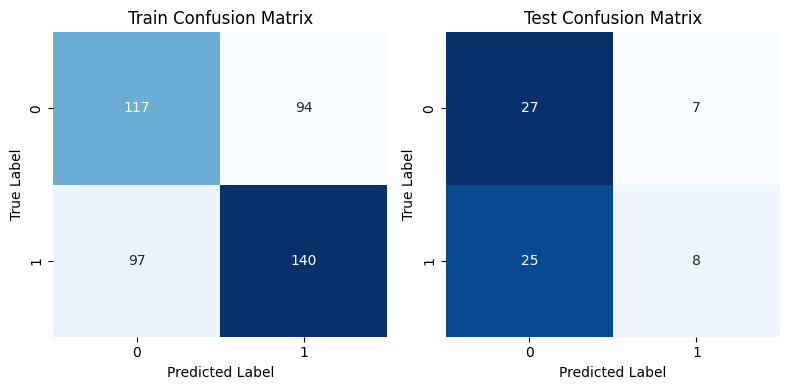

In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make predictions using the trained model
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# Convert probabilities to binary labels
train_labels = np.where(train_predictions >= 0.5, 1, 0)
test_labels = np.where(test_predictions >= 0.5, 1, 0)

# Create the confusion matrix
train_cm = confusion_matrix(y_train, train_labels)
test_cm = confusion_matrix(y_test, test_labels)

# Plot the confusion matrix as a heatmap
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

sns.heatmap(train_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[0])
ax[0].set_title("Train Confusion Matrix")
ax[0].set_xlabel("Predicted Label")
ax[0].set_ylabel("True Label")

sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax[1])
ax[1].set_title("Test Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.tight_layout()
plt.show();

# Predict

In [133]:
stock_symbol = 'VUSA.L'
start_date_ = '2023-07-14'
end_date_ = '2023-07-15'

In [134]:
# Retrieve the latest stock data
latest_data = yf.download(stock_symbol, start=start_date_, end=end_date_)

if latest_data.empty:
    print("Error: No data available for the specified stock symbol and end date.")
else:
    # Extract the 'Open' and 'Close' prices from the latest data
    latest_prices = latest_data[['Open', 'Close']].values

    # Scale the latest prices using the same scaler used for training
    scaled_latest_prices = scaler.transform(latest_prices)

    # Create a sequence for prediction
    X_pred = np.array([scaled_latest_prices[-sequence_length:, :]])

    # Make the prediction using the trained model
    prediction = model.predict(X_pred)
    predicted_label = 'up' if prediction >= 0.5 else 'down'

    print('Tomorrow\'s predicted stock performance:', predicted_label)

[*********************100%***********************]  1 of 1 completed
1/1 [==============================] - 1s 1s/step
Tomorrow's predicted stock performance: up


# Resources 🔧

## Blog Posts 📝

- Must Know Preprocessing Steps for [Deep Learning](https://python.plainenglish.io/must-know-preprocessing-steps-for-deep-learning-38903579547d?sk=4073e8bbf3883b03b953f8b969eaa974)


- Class Imbalance in [Deep Learning](https://medium.com/codex/dealing-with-class-imbalance-in-deep-learning-9ee68f49a96a)


- 5 Concrete Benefits of [Bayesian Statistics](https://towardsdatascience.com/5-concrete-benefits-of-bayesian-statistics-9acae2a8ae0d?sk=3ded97454ca2f3458665292caa411e68)


- Read all my stories and thousands from other writers on [Medium](https://boemer.medium.com/membership)

## Data and ML Courses 💻

- Introduction to Python for People in a [Rush](https://stan.store/rboemer/p/get-my-introduction-to-python-for-people-in-a-rush)


- The Statistics and Probability You Need to Get Into [Data Science](https://stan.store/rboemer/p/introduction-to-statistics-and-probability)


- Write efficient code: [Learn Python Refactoring](https://stan.store/rboemer/p/get-my-python-refactoring-minicourse-now) 
    

- Learn [Object-Oriented Programming in Python](https://www.udemy.com/course/object-oriented-programming-in-python-renato-boemer/?couponCode=REFACTORING) --> **Discount Price With This Link!!**


- From Zero to Hero in [SQL](https://www.sqlhabit.com/?ref=theminimalistprogrammer).


- More Python, Data Science and Machine Learning at [Codecademy](https://www.pntra.com/t/2-438168-303903-213588).

## Productivity 📈

- [Notion](https://affiliate.notion.so/72jw59v2d74k) is a comprehensive productivity tool that allows users to collaborate, manage projects, take notes, and create databases all within one interface. 


- [StanStore](join.stan.store/rboemer) is the easiest way to make money online. All of your courses, digital products, and bookings are now hosted in your link in bio.


- [Wise](https://wise.com/invite/dic/renatob104) is essentially an online account where you can send money abroad or get paid in other currencies, and spend abroad on their Wise debit card.

## Follow Me on Social Media 📱

- [TikTok](https://www.tiktok.com/@renatoboemer)  


- [LinkedIn](https://www.linkedin.com/in/renatoboemer/)


- [Medium](https://boemer.medium.com/membership)

Thanks and happy coding!

--**Renato** 🚀